In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amitabhajoy/bengaluru-house-price-data/Bengaluru_House_Data.csv


In [2]:
df=pd.read_csv('/kaggle/input/datasets/amitabhajoy/bengaluru-house-price-data/Bengaluru_House_Data.csv')

In [3]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
df.shape

(13320, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [7]:
import re
def transform_total_sqft(text):
    res = text
    if re.search(r' - \d+', text):
        lst = text.split(' - ')
        avg = (float(lst[0]) + float(lst[1])) / 2
        res = avg    
    else:
        res=re.search(r'\d+', text).group()
    return float(res)
    

In [8]:
df['total_sqft']=df['total_sqft'].apply(transform_total_sqft) #3285, 5464

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  float64
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(4), object(5)
memory usage: 936.7+ KB


<Figure size 1200x600 with 0 Axes>

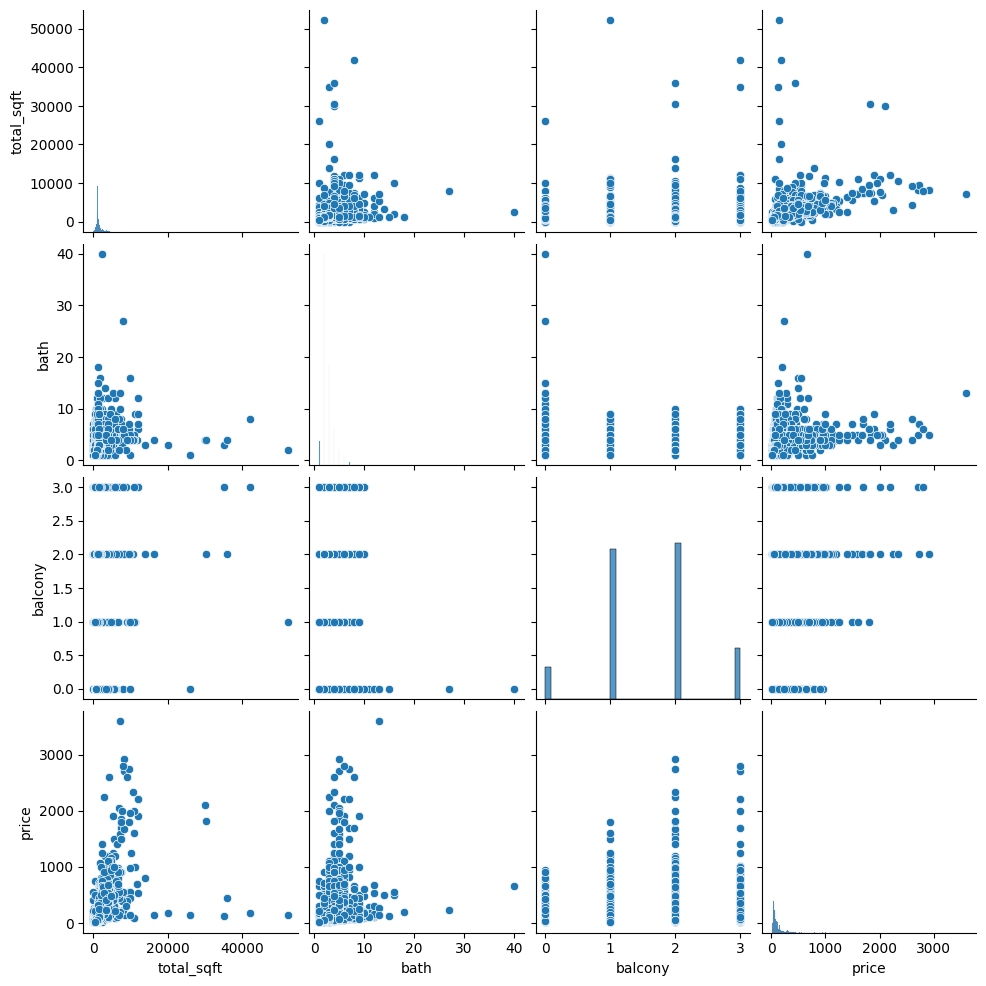

In [10]:
plt.figure(figsize=(12, 6))
sns.pairplot(df[['total_sqft', 'bath', 'balcony', 'price']])
plt.show()

<Axes: xlabel='bath', ylabel='total_sqft'>

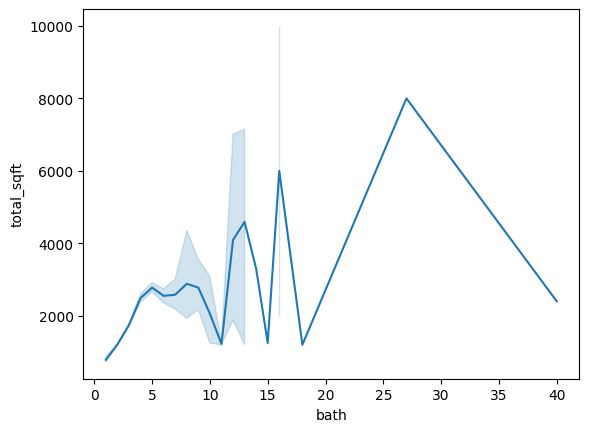

In [11]:
sns.lineplot(x=df['bath'], y=df['total_sqft'])

<Axes: xlabel='balcony', ylabel='total_sqft'>

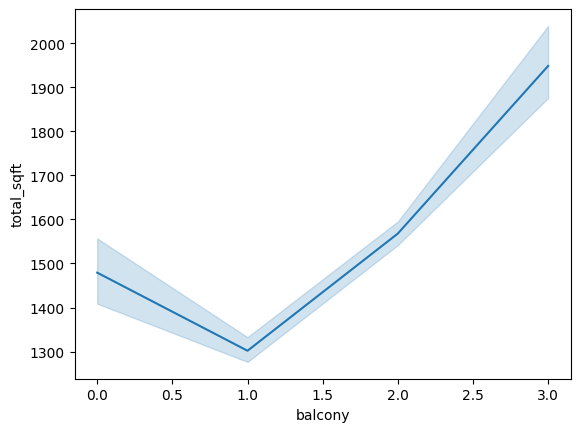

In [12]:
sns.lineplot(x=df['balcony'], y=df['total_sqft'])

<Axes: xlabel='bath', ylabel='price'>

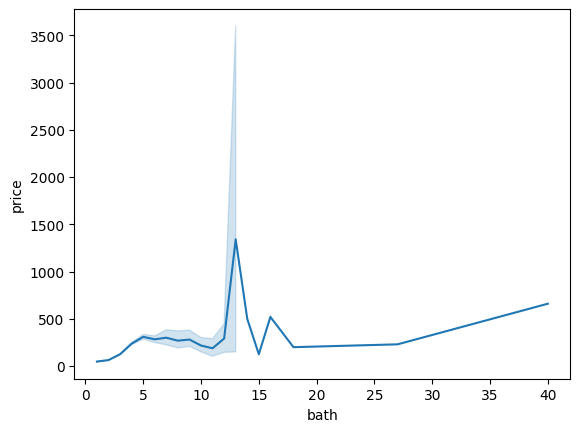

In [13]:
sns.lineplot(x=df['bath'], y=df['price'])

<Axes: xlabel='balcony', ylabel='price'>

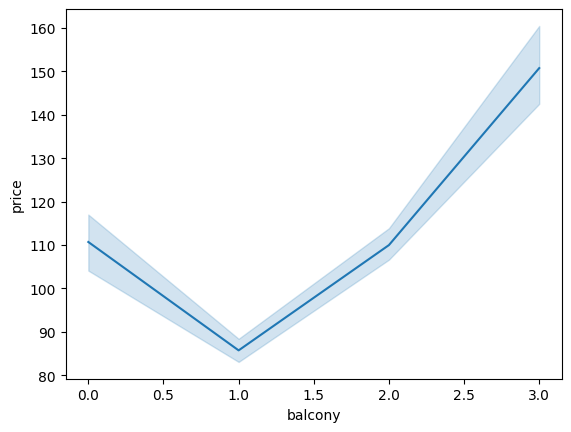

In [14]:
sns.lineplot(x=df['balcony'], y=df['price'])

In [15]:
df.drop(columns=['balcony'])

,area_type,availability,location,size,society,total_sqft,bath,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056.0,2.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600.0,5.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,51.00
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453.0,4.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600.0,5.0,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141.0,2.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689.0,4.0,488.00


In [16]:
def transform_size(txt):
    txt = str(txt).split()[0]
    return int(txt)

In [17]:
df['size'].isnull().sum()

np.int64(16)

In [18]:
df['size']=df['size'].ffill()

In [19]:
df['bath']=df['bath'].fillna(0)
df['balcony']=df['balcony'].fillna(0)

In [20]:
df['size']=df['size'].apply(transform_size)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13320 non-null  int64  
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  float64
 6   bath          13320 non-null  float64
 7   balcony       13320 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 936.7+ KB


In [21]:
df['total_rooms']=df['size']+df['bath']+df['balcony']

In [22]:
backup = df.copy()
df.drop(columns=['size', 'bath', 'balcony'], inplace=True)

In [23]:
df.sample(5)

,area_type,availability,location,society,total_sqft,price,total_rooms
9325,Plot Area,Ready To Move,1st Phase JP Nagar,NaN,1200.0,300.0,10.0
1888,Super built-up Area,Ready To Move,Dodda Nekkundi Extension,AlEcone,1188.0,73.0,7.0
8023,Built-up Area,Ready To Move,Devanahalli,Pardst,4920.0,393.5,8.0
4954,Super built-up Area,22-Jun,Hoodi,GoAirej,1430.0,110.0,6.0
10880,Super built-up Area,Ready To Move,Thanisandra,SLaceda,1188.0,39.0,5.0


In [24]:
df.loc[df['location'].isnull(), 'location'] = df.loc[df['location'].isnull(), 'society']

In [25]:
df.drop(columns=['society'], inplace=True)

In [26]:
top_locations=df['location'].value_counts().head(400).index
df['location'] = df['location'].apply(
    lambda loc: (loc.strip().lower()) if loc in top_locations else 'other'
)

In [27]:
df['availability'] = df['availability'].apply(lambda x: np.where(x == 'Ready To Move', 1, 0))

In [28]:
df['area_type'].value_counts()

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64

In [29]:
df=pd.get_dummies(df, columns=['area_type', 'location'], dtype=int, drop_first=True)

In [30]:
df.sample(5)

,availability,total_sqft,price,total_rooms,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st block jayanagar,location_1st block koramangala,location_1st phase jp nagar,...,location_vittasandra,location_volagerekallahalli,location_whitefield,location_wilson garden,location_yelachenahalli,location_yelahanka,location_yelahanka new town,location_yelenahalli,location_yemlur,location_yeshwanthpur
8473,1,973.0,56.0,5.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1331,1,1530.0,74.4,7.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7749,1,1542.0,120.0,9.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2749,1,1145.0,75.0,6.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7386,1,2075.0,175.0,7.0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['price']),df['price'], test_size=0.2, random_state=1)

In [32]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

In [33]:
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [34]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [35]:
lr.fit(x_train, y_train)

LinearRegression()

In [36]:
y_pred=lr.predict(x_test)

In [37]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.4100737777591752